In [2]:
ls

sample_data/


In [3]:
# CELL 1: INSTALLATIONS AND IMPORTS
!pip install codecarbon yfinance -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.4 MB/s eta 0:00:00


In [4]:
#Environment Setup

In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, UpSampling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import InceptionV3
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from codecarbon import EmissionsTracker

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
#Experiment 1 - Tabular Data (Feedforward Neural Network)

In [7]:
# CELL 2: TABULAR DATA & FEEDFORWARD NETWORK
print("--- STARTING EXPERIMENT 1: TABULAR FNN ---")

# 1. Generate large tabular dataset (100,000 rows, 20 features)
X_tab, y_tab = make_classification(n_samples=100000, n_features=20, n_classes=2, random_state=42)
X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(X_tab, y_tab, test_size=0.2)

# 2. Build Feedforward Neural Network
model_fnn = Sequential([
    Dense(128, activation='relu', input_shape=(20,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_fnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Track Emissions
tracker = EmissionsTracker(project_name="Tabular_FNN", measure_power_secs=1)
tracker.start()

print("Training FNN...")
history_fnn = model_fnn.fit(X_train_tab, y_train_tab, epochs=5, batch_size=64, validation_split=0.2, verbose=1)

# 4. Stop Tracking
emissions_fnn = tracker.stop()
loss, acc_fnn = model_fnn.evaluate(X_test_tab, y_test_tab, verbose=0)
print(f"FNN Accuracy: {acc_fnn:.4f} | CO2 Emitted: {emissions_fnn:.6f} kg")

--- STARTING EXPERIMENT 1: TABULAR FNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[codecarbon WARNING @ 16:45:03] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 16:45:03] [setup] RAM Tracking...
[codecarbon INFO @ 16:45:03] [setup] CPU Tracking...
[codecarbon WARNING @ 16:45:04] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 16:45:04] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 16:45:04] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subs

Training FNN...
Epoch 1/5


[codecarbon INFO @ 16:45:07] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 16:45:07] Delta energy consumed for CPU with cpu_load : 0.000004 kWh, power : 7.786152800000002 W
[codecarbon INFO @ 16:45:07] Energy consumed for All CPU : 0.000004 kWh
[codecarbon INFO @ 16:45:07] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 16:45:07] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 15.622274494866067 W
[codecarbon INFO @ 16:45:07] 0.000021 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 16:45:08] Energy consumed for RAM : 0.000007 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 16:45:08] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 7.371245600000002 W
[codecarbon INFO @ 16:45:08] Energy consumed for All CPU : 0.000005 kWh
[codecarbon INFO @ 16:45:08] Energy consumed for all GPUs : 0.000018 kWh. Total GPU Power : 26.64603612474569 W
[codecarbon INFO @ 16:45:0

  89/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7789 - loss: 0.4886

...

 980/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8734 - loss: 0.2931

[codecarbon INFO @ 16:45:34] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 3.7592436068 W
[codecarbon INFO @ 16:45:34] Energy consumed for All CPU : 0.000028 kWh
[codecarbon INFO @ 16:45:34] Energy consumed for all GPUs : 0.000213 kWh. Total GPU Power : 26.963148914533416 W
[codecarbon INFO @ 16:45:34] 0.000281 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 16:45:35] Energy consumed for RAM : 0.000043 kWh. RAM Power : 10.0 W


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8734 - loss: 0.2941 - val_accuracy: 0.8713 - val_loss: 0.2997


[codecarbon INFO @ 16:45:35] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 16:45:35] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.8329923008 W
[codecarbon INFO @ 16:45:35] Energy consumed for All CPU : 0.000028 kWh
[codecarbon INFO @ 16:45:35] Energy consumed for all GPUs : 0.000220 kWh. Total GPU Power : 27.00511872010247 W
[codecarbon INFO @ 16:45:35] 0.000292 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 16:45:35] No power samples collected, returning 0 W
[codecarbon INFO @ 16:45:36] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.0 W
[codecarbon INFO @ 16:45:36] Energy consumed for All CPU : 0.000028 kWh
[codecarbon INFO @ 16:45:36] Energy consumed for all GPUs : 0.000221 kWh. Total GPU Power : 27.18048062177953 W
[codecarbon INFO @ 16:45:36] 0.000293 kWh of electricity and 0.000000 L of water were used since the beginning.


FNN Accuracy: 0.8705 | CO2 Emitted: 0.000041 kg


In [8]:
#Experiment 2 - Computer Vision (CIFAR-10 + InceptionV3)

In [9]:
# CELL 3: COMPUTER VISION & DEEP CNN (INCEPTION)
print("\n--- STARTING EXPERIMENT 2: VISION INCEPTION ---")

# 1. Load CIFAR-10
(X_train_cv, y_train_cv), (X_test_cv, y_test_cv) = tf.keras.datasets.cifar10.load_data()
X_train_cv, X_test_cv = X_train_cv / 255.0, X_test_cv / 255.0

# 2. Build Model (Upsample 32x32 -> 96x96, then InceptionV3)
base_model = InceptionV3(weights=None, include_top=False, input_shape=(96, 96, 3))
model_cnn = Sequential([
    UpSampling2D(size=(3,3), input_shape=(32, 32, 3)), # Scales to 96x96
    base_model,
    GlobalAveragePooling2D(),
    Dense(10, activation='softmax')
])
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Track Emissions
tracker = EmissionsTracker(project_name="Vision_Inception", measure_power_secs=1)
tracker.start()

print("Training Inception CNN (This will take the most energy)...")
# Using only 3 epochs so the live demo doesn't take an hour
history_cnn = model_cnn.fit(X_train_cv, y_train_cv, epochs=3, batch_size=128, validation_split=0.2, verbose=1)

emissions_cnn = tracker.stop()
loss, acc_cnn = model_cnn.evaluate(X_test_cv, y_test_cv, verbose=0)
print(f"CNN Accuracy: {acc_cnn:.4f} | CO2 Emitted: {emissions_cnn:.6f} kg")


--- STARTING EXPERIMENT 2: VISION INCEPTION ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4308s 25us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/up_sampling2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[codecarbon WARNING @ 17:57:30] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:57:30] [setup] RAM Tracking...
[codecarbon INFO @ 17:57:30] [setup] CPU Tracking...
[codecarbon WARNING @ 17:57:30] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 17:57:30] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 17:57:30] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarb

Training Inception CNN (This will take the most energy)...


[codecarbon INFO @ 17:57:32] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W


Epoch 1/3


...

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6235 - loss: 1.0872

[codecarbon INFO @ 18:01:47] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.9029253104000001 W
[codecarbon INFO @ 18:01:47] Energy consumed for All CPU : 0.000072 kWh
[codecarbon INFO @ 18:01:47] Energy consumed for all GPUs : 0.003685 kWh. Total GPU Power : 67.0749599881225 W
[codecarbon INFO @ 18:01:47] 0.004102 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:01:48] Energy consumed for RAM : 0.000346 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:01:48] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 2.3548837184000004 W
[codecarbon INFO @ 18:01:48] Energy consumed for All CPU : 0.000073 kWh
[codecarbon INFO @ 18:01:48] Energy consumed for all GPUs : 0.003704 kWh. Total GPU Power : 67.12401449461795 W
[codecarbon INFO @ 18:01:48] 0.004123 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:01:48] 0.002755 g.CO2eq/s mean an estimation of 86.882445162911

313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.6427 - loss: 1.0442 - val_accuracy: 0.5727 - val_loss: 1.3760


[codecarbon INFO @ 18:01:50] Energy consumed for RAM : 0.000349 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:01:50] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 2.22966575 W
[codecarbon INFO @ 18:01:50] Energy consumed for All CPU : 0.000074 kWh
[codecarbon INFO @ 18:01:50] Energy consumed for all GPUs : 0.003736 kWh. Total GPU Power : 49.84853520848777 W
[codecarbon INFO @ 18:01:50] 0.004158 kWh of electricity and 0.000000 L of water were used since the beginning.


CNN Accuracy: 0.5745 | CO2 Emitted: 0.000577 kg


In [10]:
#Experiment 3 - Time Series (Bitcoin + Deep BiLSTM)

In [11]:
# CELL 4: TIME SERIES & DEEP BILSTM
print("\n--- STARTING EXPERIMENT 3: BTC TIME SERIES BILSTM ---")

# 1. Fetch 10 years of BTC Data
btc_data = yf.download('BTC-USD', period='10y')
closes = btc_data['Close'].values.reshape(-1, 1)

# 2. Preprocess (Scale and create 60-day windows)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(closes)

X_ts, y_ts = [], []
for i in range(60, len(scaled_data)):
    X_ts.append(scaled_data[i-60:i, 0])
    y_ts.append(scaled_data[i, 0])
X_ts, y_ts = np.array(X_ts), np.array(y_ts)
X_ts = np.reshape(X_ts, (X_ts.shape[0], X_ts.shape[1], 1))

X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(X_ts, y_ts, test_size=0.2, shuffle=False)

# 3. Build Deep BiLSTM
model_lstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_ts.shape[1], 1)),
    Dropout(0.2),
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 4. Track Emissions
tracker = EmissionsTracker(project_name="TimeSeries_BiLSTM", measure_power_secs=1)
tracker.start()

print("Training Deep BiLSTM...")
history_lstm = model_lstm.fit(X_train_ts, y_train_ts, epochs=5, batch_size=32, validation_split=0.1, verbose=1)

emissions_lstm = tracker.stop()
# For regression, we evaluate on Loss (MSE) rather than accuracy
loss_lstm = model_lstm.evaluate(X_test_ts, y_test_ts, verbose=0)
print(f"BiLSTM Test Loss (MSE): {loss_lstm:.6f} | CO2 Emitted: {emissions_lstm:.6f} kg")


--- STARTING EXPERIMENT 3: BTC TIME SERIES BILSTM ---


/tmp/ipykernel_2595/3741907485.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_data = yf.download('BTC-USD', period='10y')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[codecarbon WARNING @ 18:02:01] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:02:01] [setup] RAM Tracking...
[codecarbon INFO @ 18:02:01] [setup] CPU Tracking...
[codecarbon WARNING @ 18:02:01] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:02:01] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING 

Training Deep BiLSTM...
Epoch 1/5


[codecarbon INFO @ 18:02:04] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:02:04] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 1.9655261 W
[codecarbon INFO @ 18:02:04] Energy consumed for All CPU : 0.000001 kWh
[codecarbon INFO @ 18:02:04] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 18:02:04] Energy consumed for all GPUs : 0.000013 kWh. Total GPU Power : 18.616221261473807 W
[codecarbon INFO @ 18:02:04] 0.000020 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:02:05] Energy consumed for RAM : 0.000007 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:02:05] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 1.9496334500000003 W
[codecarbon INFO @ 18:02:05] Energy consumed for All CPU : 0.000001 kWh
[codecarbon INFO @ 18:02:05] Energy consumed for all GPUs : 0.000022 kWh. Total GPU Power : 32.171819951944904 W
[codecarbon INFO @ 18:02:05] 0.0

 7/81 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0183

...

53/81 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.9281e-04

[codecarbon INFO @ 18:02:15] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 4.116681796399999 W
[codecarbon INFO @ 18:02:15] Energy consumed for All CPU : 0.000006 kWh
[codecarbon INFO @ 18:02:15] Energy consumed for all GPUs : 0.000145 kWh. Total GPU Power : 52.17716297705247 W
[codecarbon INFO @ 18:02:15] 0.000172 kWh of electricity and 0.000000 L of water were used since the beginning.


81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.2986e-04 - val_loss: 8.5766e-04


[codecarbon INFO @ 18:02:15] Energy consumed for RAM : 0.000022 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:02:16] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 1.7707404895999996 W
[codecarbon INFO @ 18:02:16] Energy consumed for All CPU : 0.000007 kWh
[codecarbon INFO @ 18:02:16] Energy consumed for all GPUs : 0.000157 kWh. Total GPU Power : 44.0942971109192 W
[codecarbon INFO @ 18:02:16] 0.000185 kWh of electricity and 0.000000 L of water were used since the beginning.


BiLSTM Test Loss (MSE): 0.003877 | CO2 Emitted: 0.000026 kg


In [12]:
#Analytics and Visualization


--- RESULTS & CARBON FOOTPRINT ANALYSIS ---


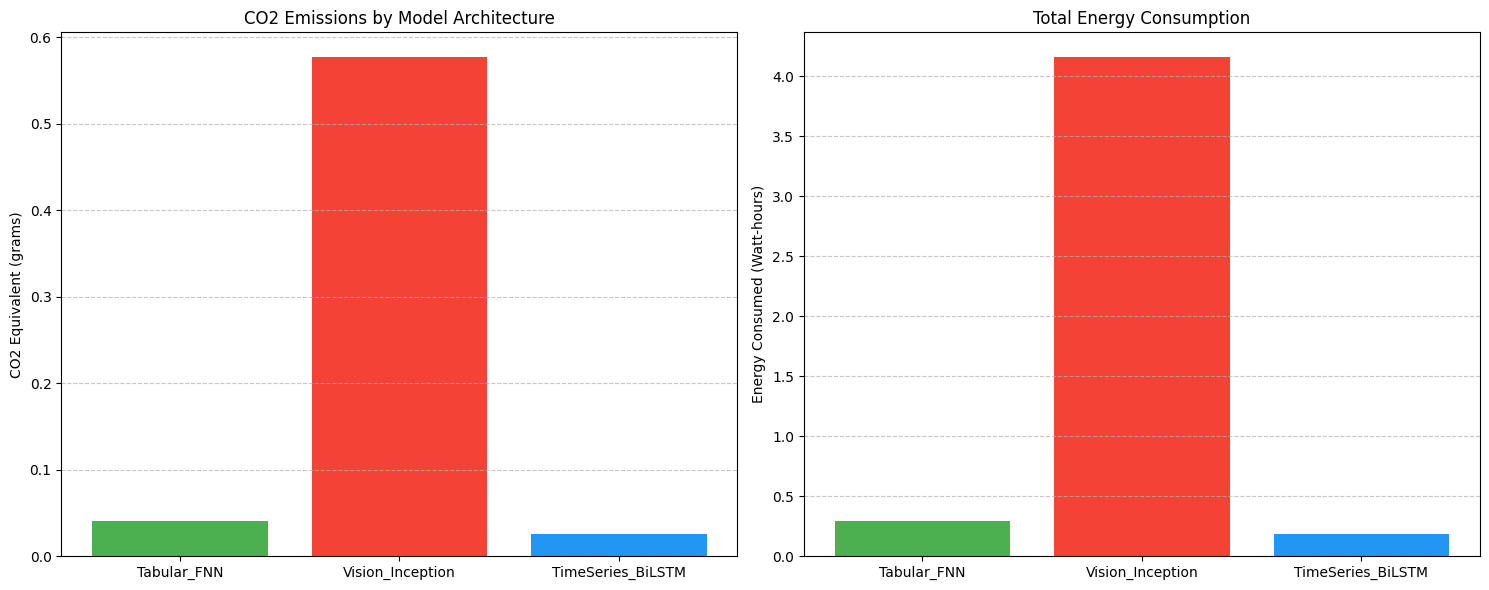


--- FINAL METRICS SUMMARY ---


,Architecture,Duration (seconds),Energy (kWh),CO2 Emitted (kg)
0,Tabular_FNN,30.697138,0.000293,0.000041
1,Vision_Inception,259.844866,0.004158,0.000577
2,TimeSeries_BiLSTM,14.503035,0.000185,0.000026


In [13]:
# CELL 5: VISUALIZE CARBON FOOTPRINT COMPARISON
print("\n--- RESULTS & CARBON FOOTPRINT ANALYSIS ---")

# Read the CSV generated by CodeCarbon
df_emissions = pd.read_csv('emissions.csv')

# Filter down to the latest run of our 3 projects
df_plot = df_emissions.drop_duplicates(subset=['project_name'], keep='last')

projects = df_plot['project_name'].values
co2_emissions = df_plot['emissions'].values * 1000  # Convert kg to grams for better readability
energy_consumed = df_plot['energy_consumed'].values * 1000 # Convert kWh to Wh

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: CO2 Emissions
bars1 = ax1.bar(projects, co2_emissions, color=['#4CAF50', '#F44336', '#2196F3'])
ax1.set_title('CO2 Emissions by Model Architecture')
ax1.set_ylabel('CO2 Equivalent (grams)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Energy Consumption
bars2 = ax2.bar(projects, energy_consumed, color=['#4CAF50', '#F44336', '#2196F3'])
ax2.set_title('Total Energy Consumption')
ax2.set_ylabel('Energy Consumed (Watt-hours)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print Final Summary Table
print("\n--- FINAL METRICS SUMMARY ---")
summary_df = df_plot[['project_name', 'duration', 'energy_consumed', 'emissions']].copy()
summary_df.columns = ['Architecture', 'Duration (seconds)', 'Energy (kWh)', 'CO2 Emitted (kg)']
display(summary_df)

In [14]:
#Setup and Model Architecture

In [15]:
# CELL 1: SETUP AND DATA PREPARATION
!pip install codecarbon -q

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from codecarbon import EmissionsTracker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Load and normalize CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Define a function to build a fresh CNN
def build_fresh_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("✅ Data loaded and CNN architecture defined. Ready for experiments.")

✅ Data loaded and CNN architecture defined. Ready for experiments.


In [16]:
#The Training Loop (10 vs 20 vs 30 Epochs)

In [17]:
# CELL 2: THE EPOCH EXPERIMENT
epochs_to_test = [10, 20, 30]
experiment_results = []

print("--- STARTING GREEN AI EPOCH EXPERIMENT ---")

for epochs in epochs_to_test:
    print(f"\n🚀 Training CNN for {epochs} Epochs...")

    # 1. Initialize fresh model
    model = build_fresh_cnn()

    # 2. Initialize CodeCarbon Tracker
    tracker = EmissionsTracker(project_name=f"CNN_{epochs}_Epochs", measure_power_secs=1)
    tracker.start()

    # 3. Train the model
    # We use a larger batch size (128) to keep Colab training fast
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=128, validation_split=0.1, verbose=1)

    # 4. Stop tracker and Evaluate
    emissions = tracker.stop()
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"✅ {epochs} Epochs Done | Accuracy: {test_acc:.4f} | CO2: {emissions:.6f} kg")

    # 5. Save results to our dictionary
    experiment_results.append({
        'Epochs': epochs,
        'Accuracy': test_acc * 100, # Convert to percentage
        'CO2_Emissions_g': emissions * 1000 # Convert kg to grams for plotting
    })

# Convert results to a DataFrame for easy viewing
df_results = pd.DataFrame(experiment_results)
display(df_results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[codecarbon WARNING @ 18:02:24] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:02:24] [setup] RAM Tracking...
[codecarbon INFO @ 18:02:24] [setup] CPU Tracking...
[codecarbon WARNING @ 18:02:24] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:02:24] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 18:02:24] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/in

--- STARTING GREEN AI EPOCH EXPERIMENT ---

🚀 Training CNN for 10 Epochs...


[codecarbon INFO @ 18:02:24] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 18:02:26] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:02:27] Delta energy consumed for CPU with cpu_load : 0.000004 kWh, power : 7.786152800000002 W
[codecarbon INFO @ 18:02:27] Energy consumed for All CPU : 0.000004 kWh
[codecarbon INFO @ 18:02:27] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 18:02:27] Energy consumed for all GPUs : 0.000013 kWh. Total GPU Power : 18.576607065713027 W
[codecarbon INFO @ 18:02:27] 0.000023 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:02:28] Energy consumed for RAM : 0.000010 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:02:29] Delta energy consumed for CPU with cpu_load : 0.000003 kWh, power : 8.0 W
[codecarbon INFO @ 18:02:29] Energy consumed for All CPU : 0.000008 kWh
[codecarbon INFO @ 18:02:29] Energy consumed for all G

Epoch 1/10


[codecarbon INFO @ 18:02:29] Energy consumed for RAM : 0.000011 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:02:30] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 7.786152800000002 W
[codecarbon INFO @ 18:02:30] Energy consumed for All CPU : 0.000009 kWh
[codecarbon INFO @ 18:02:30] Energy consumed for all GPUs : 0.000039 kWh. Total GPU Power : 31.52381407371127 W
[codecarbon INFO @ 18:02:30] 0.000059 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:02:30] Energy consumed for RAM : 0.000012 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:02:31] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 8.0 W
[codecarbon INFO @ 18:02:31] Energy consumed for All CPU : 0.000010 kWh
[codecarbon INFO @ 18:02:31] Energy consumed for all GPUs : 0.000048 kWh. Total GPU Power : 31.673591855869855 W
[codecarbon INFO @ 18:02:31] 0.000070 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon

...

[codecarbon INFO @ 18:05:21] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 2.2637926015999996 W
[codecarbon INFO @ 18:05:21] Energy consumed for All CPU : 0.000030 kWh
[codecarbon INFO @ 18:05:21] Energy consumed for all GPUs : 0.001236 kWh. Total GPU Power : 68.29504911080755 W
[codecarbon INFO @ 18:05:21] 0.001366 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:05:21] 0.002705 g.CO2eq/s mean an estimation of 85.29591250295437 kg.CO2eq/year


352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8865 - loss: 0.3221 - val_accuracy: 0.7178 - val_loss: 1.0578


[codecarbon INFO @ 18:05:21] Energy consumed for RAM : 0.000100 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:05:22] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.8004608000000001 W
[codecarbon INFO @ 18:05:22] Energy consumed for All CPU : 0.000030 kWh
[codecarbon INFO @ 18:05:22] Energy consumed for all GPUs : 0.001243 kWh. Total GPU Power : 40.94339217105439 W
[codecarbon INFO @ 18:05:22] 0.001374 kWh of electricity and 0.000000 L of water were used since the beginning.


✅ 30 Epochs Done | Accuracy: 0.7028 | CO2: 0.000191 kg


,Epochs,Accuracy,CO2_Emissions_g
0,10,68.019998,0.099049
1,20,70.060003,0.126861
2,30,70.279998,0.190611


In [18]:
#The Trade-Off Visualization

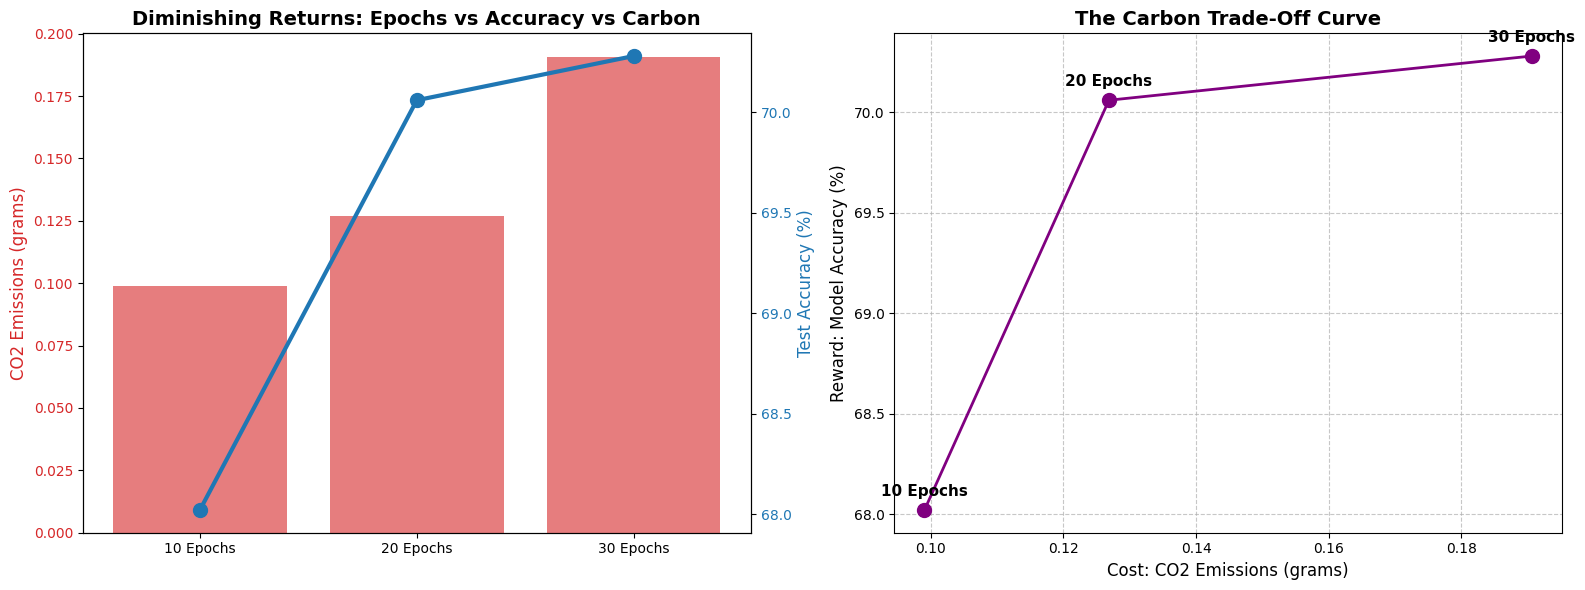

In [19]:
# CELL 3: VISUALIZING THE CARBON ROI (RETURN ON INVESTMENT)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Accuracy & Emissions vs. Epochs (Dual Axis) ---
color_acc = 'tab:blue'
color_co2 = 'tab:red'

# Bar chart for Emissions
ax1.bar(df_results['Epochs'].astype(str) + " Epochs", df_results['CO2_Emissions_g'], color=color_co2, alpha=0.6, label='CO2 Emitted (g)')
ax1.set_ylabel('CO2 Emissions (grams)', color=color_co2, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_co2)

# Line chart for Accuracy on the same plot
ax1_twin = ax1.twinx()
ax1_twin.plot(df_results['Epochs'].astype(str) + " Epochs", df_results['Accuracy'], color=color_acc, marker='o', linewidth=3, markersize=10, label='Accuracy (%)')
ax1_twin.set_ylabel('Test Accuracy (%)', color=color_acc, fontsize=12)
ax1_twin.tick_params(axis='y', labelcolor=color_acc)

ax1.set_title('Diminishing Returns: Epochs vs Accuracy vs Carbon', fontsize=14, fontweight='bold')

# --- PLOT 2: The Trade-Off Scatter Plot ---
ax2.plot(df_results['CO2_Emissions_g'], df_results['Accuracy'], marker='o', linestyle='-', color='purple', linewidth=2, markersize=10)

# Annotate the points so students know which dot is which epoch
for i, row in df_results.iterrows():
    ax2.annotate(f"{int(row['Epochs'])} Epochs",
                 (row['CO2_Emissions_g'], row['Accuracy']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=11, fontweight='bold')

ax2.set_title('The Carbon Trade-Off Curve', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cost: CO2 Emissions (grams)', fontsize=12)
ax2.set_ylabel('Reward: Model Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [20]:
###your task now###

"""
================================================================================
🟢 STUDENT LAB TASK: MEASURE YOUR OWN AI CARBON FOOTPRINT 🟢
================================================================================

Now it's your turn! We have measured Tabular, Vision, and Time Series models.
Your task is to design a 4th experiment, measure its environmental impact,
and push your findings to our GitHub repository.

📝 INSTRUCTIONS:
1. CHOOSE A DATASET: Pick any dataset you like (e.g., from sklearn, keras.datasets,
   or load a custom CSV using pandas).
2. BUILD A MODEL: Design a new architecture (e.g., Random Forest, a deeper CNN,
   or even a Transformer if you want a challenge).
3. TRACK IT: Wrap your `.fit()` training process using CodeCarbon's `EmissionsTracker`.
4. EVALUATE: Print out the final Accuracy/Loss and the total CO2 Emitted.

🚀 HOW TO SUBMIT TO GITHUB:
Once your experiment is done, you need to save your work and push it to your
forked repository, specifically into a folder named `week-10-12-ai`.

Run the following commands in a new Colab cell when you are ready to submit:

# 1. Create the target directory
!mkdir -p week-10-12-ai

# 2. Move your newly generated emissions file into the folder
!cp emissions.csv week-10-12-ai/

# 3. Add, Commit, and Push via Git
!git add week-10-12-ai/
!git commit -m "feat: added custom Green AI experiment and carbon metrics"
!git push origin main

Finally, go to your GitHub account in your browser and open a Pull Request
to the Professor's main repository!
================================================================================
"""


In [22]:
# ==========================================
# WRITE YOUR EXPERIMENT CODE BELOW THIS LINE
# ==========================================
from codecarbon import EmissionsTracker
# Your code here...

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report



# Load Dataset

print("Loading dataset...")

categories = [
    "sci.space",
    "comp.graphics",
    "rec.sport.baseball",
    "talk.politics.misc"
]

data = fetch_20newsgroups(
    subset="all",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

X = data.data
y = data.target



# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



# Build Model Pipeline

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=10000,
            stop_words="english"
        )
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            random_state=42
        )
    )
])



# Track Carbon Emissions

tracker = EmissionsTracker(
    project_name="AI Carbon Footprint"
)

tracker.start()


# Training

model.fit(
    X_train,
    y_train
)


emissions = tracker.stop()


# 5. Evaluation

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)


print("\n==============================")
print("Experiment Results")
print("==============================")

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"CO2 Emissions: {emissions:.6f} kg CO2"
)


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)


print("\nDone! emissions.csv created.")

Loading dataset...


[codecarbon WARNING @ 18:05:45] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:05:45] [setup] RAM Tracking...
[codecarbon INFO @ 18:05:45] [setup] CPU Tracking...
[codecarbon WARNING @ 18:05:45] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:05:45] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 18:05:45] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 18:05:45] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 18:05:45] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 18:05:45] [setup] GPU Tracking...
[codecarbon INFO @ 18:05:45] Tracking Nvidia GPUs via PyNVML
[code


Experiment Results
Accuracy: 0.8177
CO2 Emissions: 0.000003 kg CO2

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.86       210
           1       0.94      0.85      0.89       192
           2       0.65      0.87      0.74       196
           3       0.92      0.69      0.79       148

    accuracy                           0.82       746
   macro avg       0.85      0.81      0.82       746
weighted avg       0.84      0.82      0.82       746


Done! emissions.csv created.


In [ ]:
# ================================
# PUSH GREEN AI EXPERIMENT TO GITHUB
# ================================

!pip install PyGithub -q

from github import Github, Auth
from datetime import datetime


# ---------- GitHub Details ----------
STUDENT_TOKEN = "YOUR_GITHUB_TOKEN"

REPO_NAME = "anshul-1999/mds7-Anshul_Sharma"
TARGET_FOLDER = "week-10-12-ai"


# ---------- Connect GitHub ----------
auth = Auth.Token(STUDENT_TOKEN)

repo = Github(auth=auth).get_repo(REPO_NAME)

print("Connected to:", repo.full_name)


# ---------- Upload Files ----------

files_to_push = {

    f"{TARGET_FOLDER}/green_ai_experiment.ipynb":
        "green_ai_experiment.ipynb",

    f"{TARGET_FOLDER}/emissions.csv":
        "emissions.csv",

}


for git_path, local_file in files_to_push.items():

    with open(local_file, "rb") as f:
        content = f.read()

    try:
        repo.create_file(
            path=git_path,
            message=f"Upload {local_file}",
            content=content,
            branch="main"
        )

        print("Uploaded:", git_path)

    except Exception:

        existing = repo.get_contents(
            git_path,
            ref="main"
        )

        repo.update_file(
            path=git_path,
            message=f"Update {local_file}",
            content=content,
            sha=existing.sha,
            branch="main"
        )

        print("Updated:", git_path)



# ---------- Update Audit Trail ----------

try:

    audit_file = repo.get_contents(
        "AUDIT_TRAIL.md",
        ref="main"
    )

    current_audit = audit_file.decoded_content.decode("utf-8")


    new_entry = f"""

* **{datetime.now().strftime('%Y-%m-%d')} - Green AI Experiment:**
  Created NLP text classification pipeline using TF-IDF and Random Forest.
  Dataset: 20 Newsgroups dataset.
  Added CodeCarbon tracking to measure CO2 emissions.
  Uploaded emissions.csv with experiment results.

"""


    repo.update_file(
        path="AUDIT_TRAIL.md",
        message="Add Green AI experiment log",
        content=current_audit + new_entry,
        sha=audit_file.sha,
        branch="main"
    )

    print("✅ AUDIT_TRAIL.md Updated")


except Exception as e:

    print("Audit update error:", e)



print("\n==============================")
print("✅ ALL FILES PUSHED SUCCESSFULLY")
print("==============================")